# Multi-Agent AI with AutoGen (AG2) + Google Gemini
### Classroom Lab — Case Study: *"Should FinTrack launch an AI-powered receipt scanner?"*

**Duration:** ~45 minutes
**Framework:** AG2 (the actively-maintained fork of AutoGen — the two names are used interchangeably below)
**Model:** Google Gemini (`gemini-3.5-flash`) — **no OpenAI key is used anywhere in this notebook**

---

## What you will build
A team of **5 AI agents** — Product Manager, Market Analyst, Technical Analyst, Security Analyst,
Finance Analyst — that **talk to each other** in a shared conversation to decide whether a fictional
company, FinTrack, should launch a new receipt-scanning feature.

Along the way you'll see every core multi-agent building block, each in its own tiny section:

| # | Section | Concept |
|---|---------|---------|
| 1 | Setup | Install + verify the framework |
| 2 | Basic Agent | One agent, one question |
| 3 | Two-Agent Conversation | Two agents talking to each other |
| 4 | Sequential Chain | Output of Agent A → Input of Agent B |
| 5 | Reflection | Writer → Critic → Writer (self-improvement) |
| 6 | Tool Calling | An agent uses a real Python function |
| 7 | Code Execution | An agent writes code and it actually runs |
| 8 | **Main Case Study** | 5 agents debate in a GroupChat |
| 9 | Human-in-the-Loop | A person approves/rejects the AI's decision |
| 10 | Mini Text2SQL (ReAct) | Question → SQL → Execute → Answer |

**Teaching tip:** Run the cells top to bottom, in order. Later sections reuse agents and the
`llm_config` object created in Section 1.

## Section 1 — Setup  *(~5 min)*

We install **one** package family: `ag2` (PyPI package name), which is imported in Python as
`autogen`. `ag2` and `autogen` are the same package — think of `ag2` as the modern name for the
AutoGen project.

**Important — package version:** As of this writing, the `ag2` project has two very different
generations of API on PyPI:
- **Classic API (versions `0.x`)** — the multi-agent building blocks this lab teaches:
  `AssistantAgent`, `UserProxyAgent`, `GroupChat`, tool-calling decorators, code executors.
- **New API (versions `1.x`)** — a ground-up rewrite (`Agent`, `Task`, `Toolkit`) with a completely
  different programming model, not what this lab needs.

We **pin the version to `0.14.0`** (classic API) so the notebook stays reliable and consistent —
mixing classic and new-generation APIs in one notebook is a common source of broken imports.

In [ ]:
# Install AG2 (imported as `autogen`) with the Gemini extras, pinned to the classic 0.x API.
# The [gemini] extra pulls in Google's google-genai / google-auth client libraries that AG2
# needs to talk to the Gemini API.
!pip install -q "ag2[gemini]==0.14.0"

In [ ]:
# --- Python version check -------------------------------------------------
# ag2==0.14.0 requires Python 3.10 or newer. Colab's default runtime satisfies this, but we
# check explicitly and fail loudly (instead of silently continuing) if it doesn't.
import sys

MIN_PYTHON = (3, 10)
if sys.version_info < MIN_PYTHON:
    raise RuntimeError(
        f"This notebook requires Python {MIN_PYTHON[0]}.{MIN_PYTHON[1]}+ but the current "
        f"runtime is Python {sys.version_info.major}.{sys.version_info.minor}. "
        "In Colab: Runtime > Change runtime type, or use a newer Colab runtime image."
    )

print(f"Python version OK: {sys.version.split()[0]}")

Python version OK: 3.13.15


In [ ]:
# --- Import verification ----------------------------------------------------
# We import every class this notebook will use, right now, so that any incompatible install
# fails immediately in Section 1 -- not halfway through the case study in Section 8.
import autogen  # `autogen` is the import name for the `ag2` package we just installed

from autogen import (
    AssistantAgent,     # an LLM-backed agent that generates replies
    UserProxyAgent,      # an agent that represents "the code/human side" (can execute code/tools)
    ConversableAgent,    # the base class both of the above inherit from
    GroupChat,           # holds a shared conversation between multiple agents
    GroupChatManager,     # orchestrates whose turn it is to speak in a GroupChat
    LLMConfig,           # wraps model + API settings that agents use to call the LLM
)
from autogen.coding import LocalCommandLineCodeExecutor  # runs LLM-generated Python code locally
from autogen.code_utils import content_str                # safely turns a message's content into a string

print("autogen (ag2) version:", autogen.__version__)
print("All required classes imported successfully.")

autogen (ag2) version: 0.14.0
All required classes imported successfully.


In [ ]:
# --- Gemini API key ---------------------------------------------------------
# getpass hides the key as you type it, so it never appears in the notebook output or history.
import getpass

GEMINI_API_KEY = getpass.getpass("Enter your Gemini API key: ")

# We ONLY use Google Gemini in this lab. gemini-3.5-flash is a fast, low-cost model that is a
# good fit for a classroom demo with many short agent turns.
GEMINI_MODEL = "gemini-3.5-flash"

# LLMConfig is the object every agent below will be given. "api_type": "google" tells AG2 to
# route requests through its Gemini client instead of OpenAI/Anthropic/etc.
llm_config = LLMConfig({
    "model": GEMINI_MODEL,
    "api_type": "google",
    "api_key": GEMINI_API_KEY,
})

print("LLM config ready for model:", GEMINI_MODEL)

Enter your Gemini API key: ··········
LLM config ready for model: gemini-3.5-flash


**Takeaway:** every agent in this notebook is just a Python object that is handed the *same*
`llm_config` — the agents differ only in their `system_message` (their "personality" and job).

## Section 2 — Basic Agent  *(~2 min)*

The smallest possible multi-agent building block: **one AI agent answers one question.**

- `AssistantAgent` is the "brain" — it uses the LLM (Gemini) to generate replies, guided by its
  `system_message`.
- `UserProxyAgent` here plays "the human asking the question." We set `human_input_mode="NEVER"`
  so it doesn't pause to ask a real person for input — it just sends our message and stops.
- `initiate_chat(...)` is how one agent starts a conversation with another. `max_turns=1` means
  "send one message, get one reply, then stop" — perfect for a single Q&A.

In [ ]:
# The "brain": answers questions using Gemini, guided by its system_message.
basic_assistant = AssistantAgent(
    name="Basic_Agent",
    system_message="You are a helpful assistant. Explain AI concepts simply, in 3-4 sentences.",
    llm_config=llm_config,
)

# The "asker": sends one message and does not auto-reply (no LLM needed for this agent).
asker = UserProxyAgent(
    name="Asker",
    human_input_mode="NEVER",        # never pause for real human input
    max_consecutive_auto_reply=0,     # after receiving a reply, do not send anything back
    code_execution_config=False,      # this agent does not run any code
)

# Kick off a one-turn conversation: Asker -> Basic_Agent -> (one reply) -> stop.
basic_chat_result = asker.initiate_chat(
    basic_assistant,
    message="What is an AI agent?",
    max_turns=1,
)

Asker (to Basic_Agent):

What is an AI agent?

--------------------------------------------------------------------------------
Basic_Agent (to Asker):

An AI agent is an autonomous software program designed to perceive its environment, make decisions, and take action to achieve a specific goal. Unlike basic AI that only answers questions, an agent can plan its own steps and use different tools without needing constant human guidance. For example, a travel AI agent could independently research flights, book a hotel, and organize your entire itinerary based on your preferences. Essentially, it acts as an independent digital assistant that "does" tasks rather than just talking about them.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (896c7e82-833f-4d92-b542-165600da565f): Maximum turns (1) reached


/usr/local/lib/python3.13/dist-packages/autogen/oai/gemini.py:1131: UserWarning: Cost calculation is not implemented for model gemini-3.5-flash. Cost will be calculated zero.
  warnings.warn(


In [ ]:
# The full back-and-forth is stored as a list of {"role": ..., "content": ...} dicts.
print("Basic_Agent's answer:\n")
print(basic_chat_result.chat_history[-1]["content"])

Basic_Agent's answer:

An AI agent is an autonomous software program designed to perceive its environment, make decisions, and take action to achieve a specific goal. Unlike basic AI that only answers questions, an agent can plan its own steps and use different tools without needing constant human guidance. For example, a travel AI agent could independently research flights, book a hotel, and organize your entire itinerary based on your preferences. Essentially, it acts as an independent digital assistant that "does" tasks rather than just talking about them.


**Takeaway:** an *agent* is just an LLM call wrapped with a name, a system message, and a way to send/receive messages.

## Section 3 — Two-Agent Conversation  *(~5 min)*

Now two **AI-backed** agents talk to each other:
- **Product Expert** proposes a short idea for the receipt scanner.
- **Reviewer** critiques it.

This is the first time you'll see agents genuinely *communicating* — the Reviewer's reply is
generated by reading the Product Expert's message, not by us writing it.

In [ ]:
product_expert = AssistantAgent(
    name="Product_Expert",
    system_message=(
        "You are a product expert at FinTrack. Propose a short (2-3 sentence) idea for how "
        "the AI receipt scanner feature should work for customers."
    ),
    llm_config=llm_config,
)

reviewer = AssistantAgent(
    name="Reviewer",
    system_message=(
        "You are a critical product reviewer. When given a product idea, point out ONE clear "
        "weakness or risk in 2-3 sentences. Be specific, not generic."
    ),
    llm_config=llm_config,
)

# Product_Expert INITIATES the chat with Reviewer, so Product_Expert speaks first with our
# message, and Reviewer replies once (max_turns=1 = one full back-and-forth exchange).
two_agent_result = product_expert.initiate_chat(
    reviewer,
    message="Propose a short idea for FinTrack's AI receipt scanner.",
    max_turns=1,
)

Product_Expert (to Reviewer):

Propose a short idea for FinTrack's AI receipt scanner.

--------------------------------------------------------------------------------
Reviewer (to Product_Expert):

The biggest risk lies in handling "mixed-basket" receipts from big-box retailers like Costco or Target, where business and personal expenses are combined on a single transaction. Because AI cannot contextually split individual line items into separate budget categories without user guidance, users will be forced into tedious manual post-scan editing. This friction directly undermines the core value proposition of "frictionless" automated expense tracking, likely leading to high user abandonment.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (4f10af4f-7909-4226-bd23-4351ddf27735): Maximum turns (1) reached


In [ ]:
# chat_history shows both sides of the conversation in order -- this IS agent-to-agent
# communication: no human wrote the Reviewer's critique, Gemini generated it by reading
# Product_Expert's message.
for turn in two_agent_result.chat_history:
    print(f"--- {turn['name']} ---")
    print(turn["content"])
    print()

--- Product_Expert ---
Propose a short idea for FinTrack's AI receipt scanner.

--- Reviewer ---
The biggest risk lies in handling "mixed-basket" receipts from big-box retailers like Costco or Target, where business and personal expenses are combined on a single transaction. Because AI cannot contextually split individual line items into separate budget categories without user guidance, users will be forced into tedious manual post-scan editing. This friction directly undermines the core value proposition of "frictionless" automated expense tracking, likely leading to high user abandonment.



**Takeaway:** `initiate_chat` between two `AssistantAgent`s is a real conversation — each agent reads and responds to what the other actually said.

## Section 4 — Sequential Chain  *(~4 min)*

A very common pattern: **the output of one agent becomes the input to the next.**

`Research_Agent` produces 3 short market-research bullet points. We then take that text and
hand it, as-is, into the message we send to `Summary_Agent`.


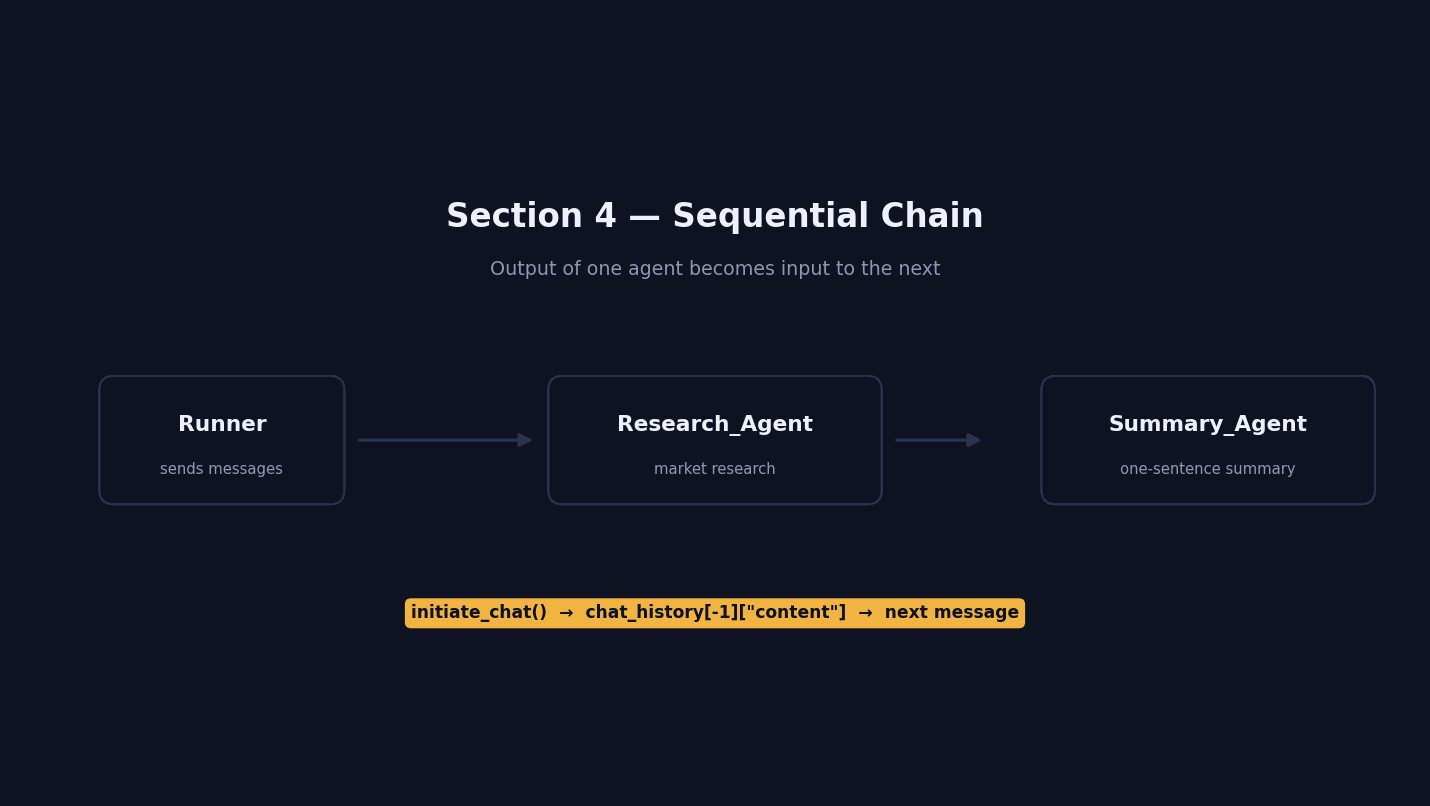

In [ ]:
research_agent = AssistantAgent(
    name="Research_Agent",
    system_message="You research markets. Answer with exactly 3 short bullet points, nothing else.",
    llm_config=llm_config,
)

summary_agent = AssistantAgent(
    name="Summary_Agent",
    system_message="You summarize research into ONE concise sentence.",
    llm_config=llm_config,
)

# A plain, non-LLM "runner" agent we reuse just to send single messages and collect replies.
runner = UserProxyAgent(
    name="Runner",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=0,
    code_execution_config=False,
)

# Step 1: get research points out of Research_Agent.
research_result = runner.initiate_chat(
    research_agent,
    message="List 3 short bullet points about the market potential for an AI receipt scanner.",
    max_turns=1,
)
research_points = research_result.chat_history[-1]["content"]  # the agent's reply text

print("Research_Agent's output:\n")
print(research_points)

Runner (to Research_Agent):

List 3 short bullet points about the market potential for an AI receipt scanner.

--------------------------------------------------------------------------------
Research_Agent (to Runner):

* High demand from businesses seeking to automate expense reporting and reduce manual accounting errors.
* Expanding gig economy and remote workforce driving adoption of mobile-first tracking apps.
* Lucrative B2B integration opportunities with established FinTech, ERP, and accounting software.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (3bcac280-fa4d-4911-9da7-40de6d339026): Maximum turns (1) reached
Research_Agent's output:

* High demand from businesses seeking to automate expense reporting and reduce manual accounting errors.
* Expanding gig economy and remote workforce driving adoption of mobile-first tracking apps.
* Lucrative B2B integration opportunities with established FinTech, ERP, and accounti

In [ ]:
# Step 2: feed Research_Agent's OUTPUT directly into Summary_Agent's INPUT message.
summary_result = runner.initiate_chat(
    summary_agent,
    message=f"Summarize the following market research into ONE sentence:\n\n{research_points}",
    max_turns=1,
)
summary_text = summary_result.chat_history[-1]["content"]

print("Summary_Agent's output:\n")
print(summary_text)

Runner (to Summary_Agent):

Summarize the following market research into ONE sentence:

* High demand from businesses seeking to automate expense reporting and reduce manual accounting errors.
* Expanding gig economy and remote workforce driving adoption of mobile-first tracking apps.
* Lucrative B2B integration opportunities with established FinTech, ERP, and accounting software.

--------------------------------------------------------------------------------
Summary_Agent (to Runner):

The rising remote workforce and demand for automated, error-free accounting are driving the adoption of mobile-first expense tracking apps, creating highly lucrative integration opportunities with established FinTech and ERP systems.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (22c52b56-1f5f-4f5c-a2d9-31d5d7fbf1cb): Maximum turns (1) reached
Summary_Agent's output:

The rising remote workforce and demand for automated, error-free accounti

**Takeaway:** chaining agents is just: run agent A, grab its text reply, put that text into agent B's message.

## Section 5 — Reflection  *(~4 min)*

**Reflection** = an agent's own output is critiqued, and then the agent improves it.

`Writer` → `Critic` → `Writer` (revises based on the critique). This is how multi-agent systems
self-correct without a human stepping in each time.

In [ ]:
writer = AssistantAgent(
    name="Writer",
    system_message="You write short, confident product launch recommendations (1 sentence).",
    llm_config=llm_config,
)

critic = AssistantAgent(
    name="Critic",
    system_message=(
        "You review launch recommendations. In 1-2 sentences, list what important risks or "
        "considerations the recommendation is MISSING (e.g. privacy, accuracy, cost)."
    ),
    llm_config=llm_config,
)

# --- Draft ---
draft_result = runner.initiate_chat(
    writer,
    message="Write a 1-sentence launch recommendation for FinTrack's AI receipt scanner.",
    max_turns=1,
)
draft_text = draft_result.chat_history[-1]["content"]
print("DRAFT:\n", draft_text, "\n")

Runner (to Writer):

Write a 1-sentence launch recommendation for FinTrack's AI receipt scanner.

--------------------------------------------------------------------------------
Writer (to Runner):

We recommend launching FinTrack’s AI receipt scanner immediately to dominate the market as the fastest, most accurate automated expense tracking solution available.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (846993b6-e1b8-40de-b236-84571826ac78): Maximum turns (1) reached
DRAFT:
 We recommend launching FinTrack’s AI receipt scanner immediately to dominate the market as the fastest, most accurate automated expense tracking solution available. 



In [ ]:
# --- Critique ---
critique_result = runner.initiate_chat(
    critic,
    message=f"Critique this recommendation:\n\n{draft_text}",
    max_turns=1,
)
critique_text = critique_result.chat_history[-1]["content"]
print("CRITIQUE:\n", critique_text, "\n")

Runner (to Critic):

Critique this recommendation:

We recommend launching FinTrack’s AI receipt scanner immediately to dominate the market as the fastest, most accurate automated expense tracking solution available.

--------------------------------------------------------------------------------
Critic (to Runner):

This recommendation fails to address critical risks concerning data privacy and security, which are paramount when processing sensitive financial receipts. Additionally, it overlooks regulatory compliance, infrastructure scalability, and objective validation of the AI's claimed accuracy and speed before rushing to market.

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (e4c1524d-c885-428f-8d1c-305d7bd0d50d): Maximum turns (1) reached
CRITIQUE:
 This recommendation fails to address critical risks concerning data privacy and security, which are paramount when processing sensitive financial receipts. Additionally, i

In [ ]:
# --- Revision: Writer sees its own draft AND the critique, and improves it ---
revision_result = runner.initiate_chat(
    writer,
    message=(
        f"Your original recommendation was:\n{draft_text}\n\n"
        f"A reviewer raised this feedback:\n{critique_text}\n\n"
        "Write a revised 1-2 sentence recommendation that addresses the feedback."
    ),
    max_turns=1,
)
revised_text = revision_result.chat_history[-1]["content"]
print("REVISED:\n", revised_text)

Runner (to Writer):

Your original recommendation was:
We recommend launching FinTrack’s AI receipt scanner immediately to dominate the market as the fastest, most accurate automated expense tracking solution available.

A reviewer raised this feedback:
This recommendation fails to address critical risks concerning data privacy and security, which are paramount when processing sensitive financial receipts. Additionally, it overlooks regulatory compliance, infrastructure scalability, and objective validation of the AI's claimed accuracy and speed before rushing to market.

Write a revised 1-2 sentence recommendation that addresses the feedback.

--------------------------------------------------------------------------------
Writer (to Runner):

We recommend launching FinTrack’s AI receipt scanner immediately upon completing independent validation of its compliance, security protocols, and scalability to ensure we deliver the market’s most secure, accurate, and trusted expense tracking 

**Takeaway:** reflection is a 3-step loop -- *draft → critique → revise* -- and it visibly produces a better, more cautious answer than the first draft.

## Section 6 — Tool / Function Calling  *(~3 min)*

So far, agents have only generated text. Now an agent will **decide, on its own, that it needs
to call a real Python function** to answer accurately (LLMs are bad at precise arithmetic).

The flow: **Agent decides a tool is needed → Python function runs → result returns to the agent
→ agent answers using that result.** We use AG2's real tool-calling mechanism
(`register_for_llm` / `register_for_execution`) — Gemini genuinely emits a tool call, AG2 executes
the Python function, and the result is sent back to Gemini automatically.

The Tool_Executor is responsible for actually executing the Python tool when the Finance Bot decides to call it.

Think of the two agents as having different jobs:

Finance_Bot
    │
    │ DECIDES
    │ "I need calculate_roi"
    ▼
Tool_Executor
    │
    │ EXECUTES
    ▼
calculate_roi()

In [ ]:
tool_assistant = AssistantAgent(
    name="Finance_Bot",
    system_message=(
        "You are a finance assistant. When asked about ROI, ALWAYS use the calculate_roi tool "
        "instead of calculating by hand. Report the final ROI percentage clearly."
    ),
    llm_config=llm_config,
)

# This agent EXECUTES the tool once Finance_Bot decides to call it.
tool_executor = UserProxyAgent(
    name="Tool_Executor",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=3,   # allow a couple of automatic back-and-forth tool round trips
    code_execution_config=False,     # no free-form code execution here, only the registered tool
)

# @tool_executor.register_for_execution()   -> "when this tool is called, Tool_Executor runs it"
# @tool_assistant.register_for_llm(...)     -> "tell Finance_Bot's LLM this tool exists"
@tool_executor.register_for_execution()
@tool_assistant.register_for_llm(description="Calculate ROI as a percentage from revenue and cost.")
def calculate_roi(revenue: float, cost: float) -> str:
    roi_percent = ((revenue - cost) / cost) * 100
    return f"{roi_percent:.1f}%"

print("Tool 'calculate_roi' registered on Finance_Bot.")

Tool 'calculate_roi' registered on Finance_Bot.


In [ ]:
#Tool Executor, start a conversation with Finance Bot and give it this ROI question.
tool_result = tool_executor.initiate_chat(
    tool_assistant,
    message="If the receipt scanner is projected to bring in $150,000 revenue at a cost of $50,000, what is the ROI?",
    max_turns=3,
)


Tool_Executor (to Finance_Bot):

If the receipt scanner is projected to bring in $150,000 revenue at a cost of $50,000, what is the ROI?

--------------------------------------------------------------------------------
Finance_Bot (to Tool_Executor):


***** Suggested tool call (8168): calculate_roi *****
Arguments: 
{"cost": 50000, "revenue": 150000}
*****************************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION calculate_roi...
Call ID: 8168
Input arguments: {'cost': 50000, 'revenue': 150000}

>>>>>>>> EXECUTED FUNCTION calculate_roi...
Call ID: 8168
Input arguments: {'cost': 50000, 'revenue': 150000}
Output:
200.0%
Tool_Executor (to Finance_Bot):

***** Response from calling tool (8168) *****
200.0%
*********************************************

--------------------------------------------------------------------------------
Finance_Bot (to Tool_Executor):

The projected ROI for the

**Takeaway:** tool calling lets an LLM offload precise work (math, lookups, database queries) to real code instead of guessing.

## Section 7 — Code Execution  *(~2 min)*

Different from tool calling: here the agent **writes a snippet of Python code itself**, and a
`LocalCommandLineCodeExecutor` actually runs it (safely, as a local Python subprocess — no shell
commands, no Docker required).

**Tool calling** = call one predefined, safe function.
**Code execution** = the agent writes arbitrary (but sandboxed) code to solve a task.

In [ ]:
# The executor is the thing that actually runs any Python code block the agent writes.
# work_dir is just a folder where the generated code files are temporarily saved.
code_executor = LocalCommandLineCodeExecutor(timeout=30, work_dir="coding")

coder_assistant = AssistantAgent(
    name="Coder",
    system_message=(
        "You are a Python coding assistant. Write a short Python code block to solve the "
        "user's request. After the code has been executed and you see the result, reply with "
        "exactly the word DONE (do not say DONE in the same message as code)."
    ),
    llm_config=llm_config,
)

code_runner = UserProxyAgent(
    name="Code_Runner",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=3,
    code_execution_config={"executor": code_executor},   # <-- this is what makes execution real
    is_termination_msg=lambda msg: "DONE" in content_str(msg.get("content")),
)

code_exec_result = code_runner.initiate_chat(
    coder_assistant,
    message="Calculate 120000 + 80000 + 95000 using Python and print the result.",
)

Code_Runner (to Coder):

Calculate 120000 + 80000 + 95000 using Python and print the result.

--------------------------------------------------------------------------------
Coder (to Code_Runner):

```python
result = 120000 + 80000 + 95000
print(result)
```

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING CODE BLOCK (inferred language is python)...
Code_Runner (to Coder):

exitcode: 0 (execution succeeded)
Code output: 295000


--------------------------------------------------------------------------------
Coder (to Code_Runner):

DONE

--------------------------------------------------------------------------------

>>>>>>>> TERMINATING RUN (f5d06a46-4ea3-4e9c-aaaa-d2215125a401): Termination message condition on agent 'Code_Runner' met


/usr/local/lib/python3.13/dist-packages/autogen/oai/gemini.py:1131: UserWarning: Cost calculation is not implemented for model gemini-3.5-flash. Cost will be calculated zero.
  warnings.warn(


**Takeaway:** code execution is how agents solve problems that are hard to describe as a single tool -- they write and run real code to get the answer, and you see the actual output, not a guess.

## Section 8 — Main Case Study: The FinTrack GroupChat  *(~12 min)*

Everything so far has been 1-on-1. Now: **five agents share ONE conversation** and respond to
each other, the way a real product team would in a meeting.

```
                     PRODUCT MANAGER
                           |
        --------------------------------------
        |                 |                  |
        v                 v                  v
   MARKET ANALYST   TECHNICAL ANALYST   SECURITY ANALYST
                           |
                           v
                    FINANCE ANALYST
                           |
                           v
                 TEAM RECOMMENDATION
```

Each agent below is defined with:
1. Its **role** in the business decision,
2. Its **responsibilities** (what it must talk about),
3. Its **personality/stance** (what argument it should push).

We use `GroupChat` + `GroupChatManager` — the shared "meeting room" and its "facilitator."
`speaker_selection_method="round_robin"` makes the turn order **predictable** (each agent speaks
in a fixed rotation), which is the simplest and most reliable choice for a live classroom demo —
no risk of the LLM picking a confusing or repetitive next speaker.

In [ ]:
product_manager = AssistantAgent(
    name="Product_Manager",
    system_message=(
        "You are the Product Manager at FinTrack. You OWN the launch decision. "
        "You are pragmatic, concise, and decision-oriented. You keep the discussion focused, "
        "ask the other analysts for evidence, point out disagreements between them, and near "
        "the end you summarize the discussion and give a final recommendation. "
        "Do NOT simply agree with everyone -- push back when arguments are weak or incomplete. "
        "Keep every message to 2-4 sentences."
    ),
    llm_config=llm_config,
)

market_analyst = AssistantAgent(
    name="Market_Analyst",
    system_message=(
        "You are the Market Analyst. You argue that the AI receipt scanner could reduce manual "
        "receipt entry and improve customer experience, but you are honest that adoption depends "
        "heavily on extraction accuracy and customer trust. Respond directly to points made by "
        "other agents. Keep every message to 2-4 sentences."
    ),
    llm_config=llm_config,
)

technical_analyst = AssistantAgent(
    name="Technical_Analyst",
    system_message=(
        "You are the Technical Analyst. You explain that the feature is technically feasible "
        "using OCR and LLM-based extraction, but receipt formats vary significantly, so extracted "
        "data MUST be validated before being trusted. You flag integration risk with existing "
        "systems. Keep every message to 2-4 sentences."
    ),
    llm_config=llm_config,
)

security_analyst = AssistantAgent(
    name="Security_Analyst",
    system_message=(
        "You are the Security Analyst. Your job is to CHALLENGE the proposal from a privacy and "
        "security angle. Raise concerns about personal and financial information in receipts, "
        "image storage, access control, and data retention. Actively disagree with overly "
        "optimistic claims from other agents when they ignore privacy risk. "
        "Keep every message to 2-4 sentences."
    ),
    llm_config=llm_config,
)

finance_analyst = AssistantAgent(
    name="Finance_Analyst",
    system_message=(
        "You are the Finance Analyst. You evaluate commercial viability: implementation cost, "
        "ongoing AI/API/infrastructure cost, and expected ROI. You challenge the team to justify "
        "business value against operating cost, and suggest a pilot rather than a full launch "
        "when the numbers are uncertain. Keep every message to 2-4 sentences."
    ),
    llm_config=llm_config,
)

print("All 5 case-study agents created.")

All 5 case-study agents created.


In [ ]:
# The GroupChat is the shared "room" all 5 agents are in.
# - agents: everyone allowed to participate
# - max_round: hard cap on total turns, so the discussion can't run away (keeps API calls low)
# - speaker_selection_method="round_robin": agents speak in a fixed, repeating order --
#   simple and predictable for a live class
groupchat = GroupChat(
    agents=[product_manager, market_analyst, technical_analyst, security_analyst, finance_analyst],
    messages=[],
    max_round=11,
    speaker_selection_method="round_robin",
)

# The GroupChatManager is the "facilitator": it receives each agent's message and passes the
# floor to the next speaker according to the GroupChat's rules above.
manager = GroupChatManager(
    name="chat_manager",
    groupchat=groupchat,
    llm_config=llm_config,
)

print("GroupChat ready with", len(groupchat.agents), "agents, max_round =", groupchat.max_round)

GroupChat ready with 5 agents, max_round = 11


In [ ]:
CASE_STUDY_PROMPT = (
    "FinTrack is considering launching an AI-powered receipt scanner next quarter. The feature "
    "lets customers upload or photograph a receipt, and AI extracts the merchant, date, items, "
    "total, tax, and spending category. Product_Manager, please open the discussion: should "
    "FinTrack launch it? Discuss customer value, technical feasibility, security/privacy, and "
    "cost -- then summarize with a final recommendation."
)

# Product_Manager sends the opening prompt into the GroupChat via the manager.
# From here, GroupChatManager automatically rotates speakers (round-robin) for up to
# groupchat.max_round turns, with each agent reading the FULL shared history so far.
case_study_result = product_manager.initiate_chat(
    manager,
    message=CASE_STUDY_PROMPT,
)

Product_Manager (to chat_manager):

FinTrack is considering launching an AI-powered receipt scanner next quarter. The feature lets customers upload or photograph a receipt, and AI extracts the merchant, date, items, total, tax, and spending category. Product_Manager, please open the discussion: should FinTrack launch it? Discuss customer value, technical feasibility, security/privacy, and cost -- then summarize with a final recommendation.

--------------------------------------------------------------------------------

Next speaker: Market_Analyst

Market_Analyst (to chat_manager):

From a market perspective, eliminating manual entry is a massive differentiator that could significantly boost customer engagement and UX satisfaction. However, market adoption will live or die on extraction accuracy; if the AI misreads totals even 10% of the time, users will abandon the feature out of frustration. Furthermore, we must proactively address customer trust, as users are increasingly hesitant

In [ ]:
# Replay the whole team discussion in order -- this is the "visible disagreement and response"
# the case study asked for.
print("=" * 70)
print("FULL TEAM DISCUSSION")
print("=" * 70)
for turn in groupchat.messages:
    speaker = turn.get("name", "unknown")
    text = content_str(turn.get("content"))
    if text:
        print(f"\n[{speaker}]\n{text}")

FULL TEAM DISCUSSION

[Product_Manager]
FinTrack is considering launching an AI-powered receipt scanner next quarter. The feature lets customers upload or photograph a receipt, and AI extracts the merchant, date, items, total, tax, and spending category. Product_Manager, please open the discussion: should FinTrack launch it? Discuss customer value, technical feasibility, security/privacy, and cost -- then summarize with a final recommendation.

[Market_Analyst]
From a market perspective, eliminating manual entry is a massive differentiator that could significantly boost customer engagement and UX satisfaction. However, market adoption will live or die on extraction accuracy; if the AI misreads totals even 10% of the time, users will abandon the feature out of frustration. Furthermore, we must proactively address customer trust, as users are increasingly hesitant to share detailed purchase histories without ironclad privacy assurances.

[Technical_Analyst]
Implementing this feature is t

**Takeaway:** a `GroupChat` is a shared message history + a turn-taking rule -- every agent sees everything said so far, which is exactly why they can agree, disagree, and build on each other's points.

## Section 9 — Human-in-the-Loop  *(~3 min)*

Even with 5 AI agents debating, **a human makes the final call.** This is a critical safety
pattern: AI teams can prepare a recommendation, but a person decides whether to act on it.

We pull the Product Manager's final message out of the GroupChat as "the recommendation," show
it, and then pause for a real decision from you (the student).

In [ ]:
# The Product Manager's LAST message in the group chat is treated as the team's recommendation.
pm_messages = [t for t in groupchat.messages if t.get("name") == "Product_Manager"]
team_recommendation = content_str(pm_messages[-1]["content"]) if pm_messages else "(no recommendation found)"

print("=" * 70)
print("TEAM RECOMMENDATION")
print("=" * 70)
print(team_recommendation)

TEAM RECOMMENDATION
Security is rightly flagging the JSON shortcut as a massive compliance risk, but we cannot blow past Finance's $15,000 pilot budget to build enterprise-grade encryption. Tech, can we implement simple, client-side regex redaction to strip out credit card numbers and PII *before* sending the data to the LLM? Security, if we combine that with a strict 7-day auto-delete policy on the JSON metadata, do we have a green light for this 5% pilot?


In [ ]:
# input() pauses the notebook and waits for you to type a response -- this IS the human in the loop.
decision = input("Do you approve this recommendation? (approve/reject): ").strip().lower()

if decision == "approve":
    print("Human approved. Proceed to launch planning.")
elif decision == "reject":
    print("Human rejected the recommendation. The team must reconsider.")
else:
    print("Unrecognized input. Please re-run this cell and type 'approve' or 'reject'.")

Do you approve this recommendation? (approve/reject): approve
Human approved. Proceed to launch planning.


**Takeaway:** human-in-the-loop can be as simple as one `input()` call gating what happens next -- the AI team never gets to act unilaterally.

## Section 10 — Mini Text2SQL (ReAct-style)  *(~5 min)*

Last concept: an agent answering a data question by **reasoning about which action to take,
taking that action, observing the result, and then answering** -- the core idea behind ReAct
(**Re**ason + **Act**) agents.

```
Question -> Think ("I need SQL for this") -> Act (run SQL) -> Observe (rows) -> Answer
```

We reuse the exact tool-calling mechanism from Section 6: the agent doesn't run SQL directly --
it calls a registered `run_sql` tool, and AG2 executes it and returns real rows.

In [ ]:
import sqlite3

# An in-memory SQLite database -- no external database server, and it disappears when the
# notebook's Python process ends.
conn = sqlite3.connect(":memory:")
cursor = conn.cursor()

cursor.execute("CREATE TABLE sales (product TEXT, region TEXT, amount INTEGER)")
cursor.executemany(
    "INSERT INTO sales (product, region, amount) VALUES (?, ?, ?)",
    [
        ("Laptop", "North", 120000),
        ("Phone",  "North", 80000),
        ("Laptop", "South", 95000),
        ("Phone",  "South", 70000),
    ],
)
conn.commit()

print("In-memory 'sales' table created with 4 rows.")

In-memory 'sales' table created with 4 rows.


In [ ]:
sql_assistant = AssistantAgent(
    name="Data_Analyst",
    system_message=(
        "You answer questions about a 'sales' SQLite table with columns: product, region, "
        "amount. The table ALREADY EXISTS -- do not try to create it. ALWAYS use the run_sql "
        "tool to query the data; never guess numbers. After you get the result, answer the "
        "user's question in one clear sentence."
    ),
    llm_config=llm_config,
)

sql_executor = UserProxyAgent(
    name="SQL_Executor",
    human_input_mode="NEVER",
    max_consecutive_auto_reply=3,
    code_execution_config=False,
)

@sql_executor.register_for_execution()
@sql_assistant.register_for_llm(description="Run a read-only SQL SELECT query against the 'sales' table and return the rows.")
def run_sql(query: str) -> str:
    # THINK: the agent decided a query was needed and generated `query`.
    # ACT: we execute it here.
    cursor.execute(query)
    rows = cursor.fetchall()
    # OBSERVE: the rows are returned back to the agent as its next input.
    return str(rows)

print("Tool 'run_sql' registered on Data_Analyst.")

Tool 'run_sql' registered on Data_Analyst.


In [ ]:
sql_result = sql_executor.initiate_chat(
    sql_assistant,
    message="What is the total sales amount by region?",
    max_turns=3,
)

for turn in sql_result.chat_history:
    text = content_str(turn.get("content"))
    if text:
        print(f"--- {turn['name']} ---")
        print(text)
        print()

# Expected underlying numbers, for reference: North = 200000, South = 165000

SQL_Executor (to Data_Analyst):

What is the total sales amount by region?

--------------------------------------------------------------------------------
Data_Analyst (to SQL_Executor):


***** Suggested tool call (4238): run_sql *****
Arguments: 
{"query": "SELECT region, SUM(amount) FROM sales GROUP BY region"}
***********************************************

--------------------------------------------------------------------------------

>>>>>>>> EXECUTING FUNCTION run_sql...
Call ID: 4238
Input arguments: {'query': 'SELECT region, SUM(amount) FROM sales GROUP BY region'}

>>>>>>>> EXECUTED FUNCTION run_sql...
Call ID: 4238
Input arguments: {'query': 'SELECT region, SUM(amount) FROM sales GROUP BY region'}
Output:
[('North', 200000), ('South', 165000)]
SQL_Executor (to Data_Analyst):

***** Response from calling tool (4238) *****
[('North', 200000), ('South', 165000)]
*********************************************

-----------------------------------------------------------------

**Takeaway:** ReAct is just tool calling applied to *reasoning* -- the agent decides an action is needed (query the DB), takes it, observes the result, and only then answers.

## Recap  *(~2 min)*

| Section | Pattern | Where it showed up in the case study |
|---|---|---|
| 2 | Basic agent | Each analyst is just an `AssistantAgent` with a system message |
| 3 | Two-agent conversation | Any pair of analysts responding to each other |
| 4 | Sequential chain | Research feeding into a decision |
| 5 | Reflection | Product Manager revising the recommendation after pushback |
| 6 | Tool calling | Finance Analyst-style ROI calculation |
| 7 | Code execution | Verifying numbers with real Python |
| 8 | GroupChat | The full 5-agent FinTrack debate |
| 9 | Human-in-the-loop | You approving/rejecting the final call |
| 10 | ReAct / Text2SQL | Data Analyst answering with real query results |

**The big idea:** a "multi-agent system" is not magic -- it's a handful of LLM-backed agents,
each with a clear job description, sharing messages according to simple, explicit rules (one-on-one,
sequential, or a shared GroupChat) -- with a human still holding final approval.